# Interacting with Nematics3D figures

This notebook introduces the interactive behavior of Nematics3D figures.

We will use one simple example dataset and one quick visualization helper to open an interactive figure window. The main goal is not the plotting code itself, but what you can do with the figure after it opens.

We will introduce three groups of interactions:

- the built-in PyVista or VTK camera interactions
- the repository-specific interactions attached to plotted glyphs
- the most common functions of the live control panel


## Setup

**For readers who are only interested in the tutorial, this section can be safely skipped.** The next cells import the package, locate the repository, and load one bundled example dataset.

In [1]:
from pathlib import Path
import sys

import numpy as np

from IPython.display import Image, display


def find_repo_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent]
    for candidate in candidates:
        if (candidate / "example" / "data" / "Q_example_workflow.npy").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the repository root from the current working directory."
    )


REPO_ROOT = find_repo_root()

try:
    import nematics3d
except ModuleNotFoundError:
    sys.path.insert(0, str(REPO_ROOT / "src"))
    import nematics3d

DATA_PATH = REPO_ROOT / "example" / "data" / "Q_example_workflow.npy"

print(f"Repository root: {REPO_ROOT}")
print(f"Data file: {DATA_PATH}")


Repository root: D:\Document\GitHub\Nematics3D
Data file: D:\Document\GitHub\Nematics3D\example\data\Q_example_workflow.npy


In [2]:
Q_data = np.load(DATA_PATH)
Q_data.shape


(200, 100, 100, 5)

## Open one interactive figure

We open one figure with a minimal call. This should create an interactive PyVista window.

In this figure:

- the disclination lines are plotted as tube-like glyph objects
- the director plane is plotted with rod-like glyph objects
- the bounds are plotted as the outer box of the system

A typical result is shown below. The exact window layout, toolbar placement, menu-bar appearance, and font rendering may vary across local environments, but the main plotted content should look similar.

In [3]:
Q_obj, figure_example = nematics3d.quick_visualize_Q(
    Q=Q_data,
)


[PROGRESS]
        <QFieldObject.__init__> 
        Start to initialize Q tensor `Q`.
[PROGRESS]
        <QFieldObject.__init__> 
        Start defect analysis as detecting defects and classifying them into distinct lines for Q tensor `Q` 
        This operation might take a while.
        You can disable this automatic operation by setting is_detect_defects=False and is_classify_lines=False when initializing the Q tensor.
[INFO]
            <QFieldObject[name='Q'].act_defect_detect> 
            1270 defects are found.
[INFO]
            <QFieldObject[name='Q'].act_lines_classify> 
            8 lines are found.
[PROGRESS]
        <QFieldObject.__init__> 
        Defect analysis is finished, with 1.70 s
[INFO]
        <QFieldObject[name='Q'].act_lines_smooth> 
        There are 8 disclination lines in total, with 7 lines are smoothed.
        The smoothing window length is: 41


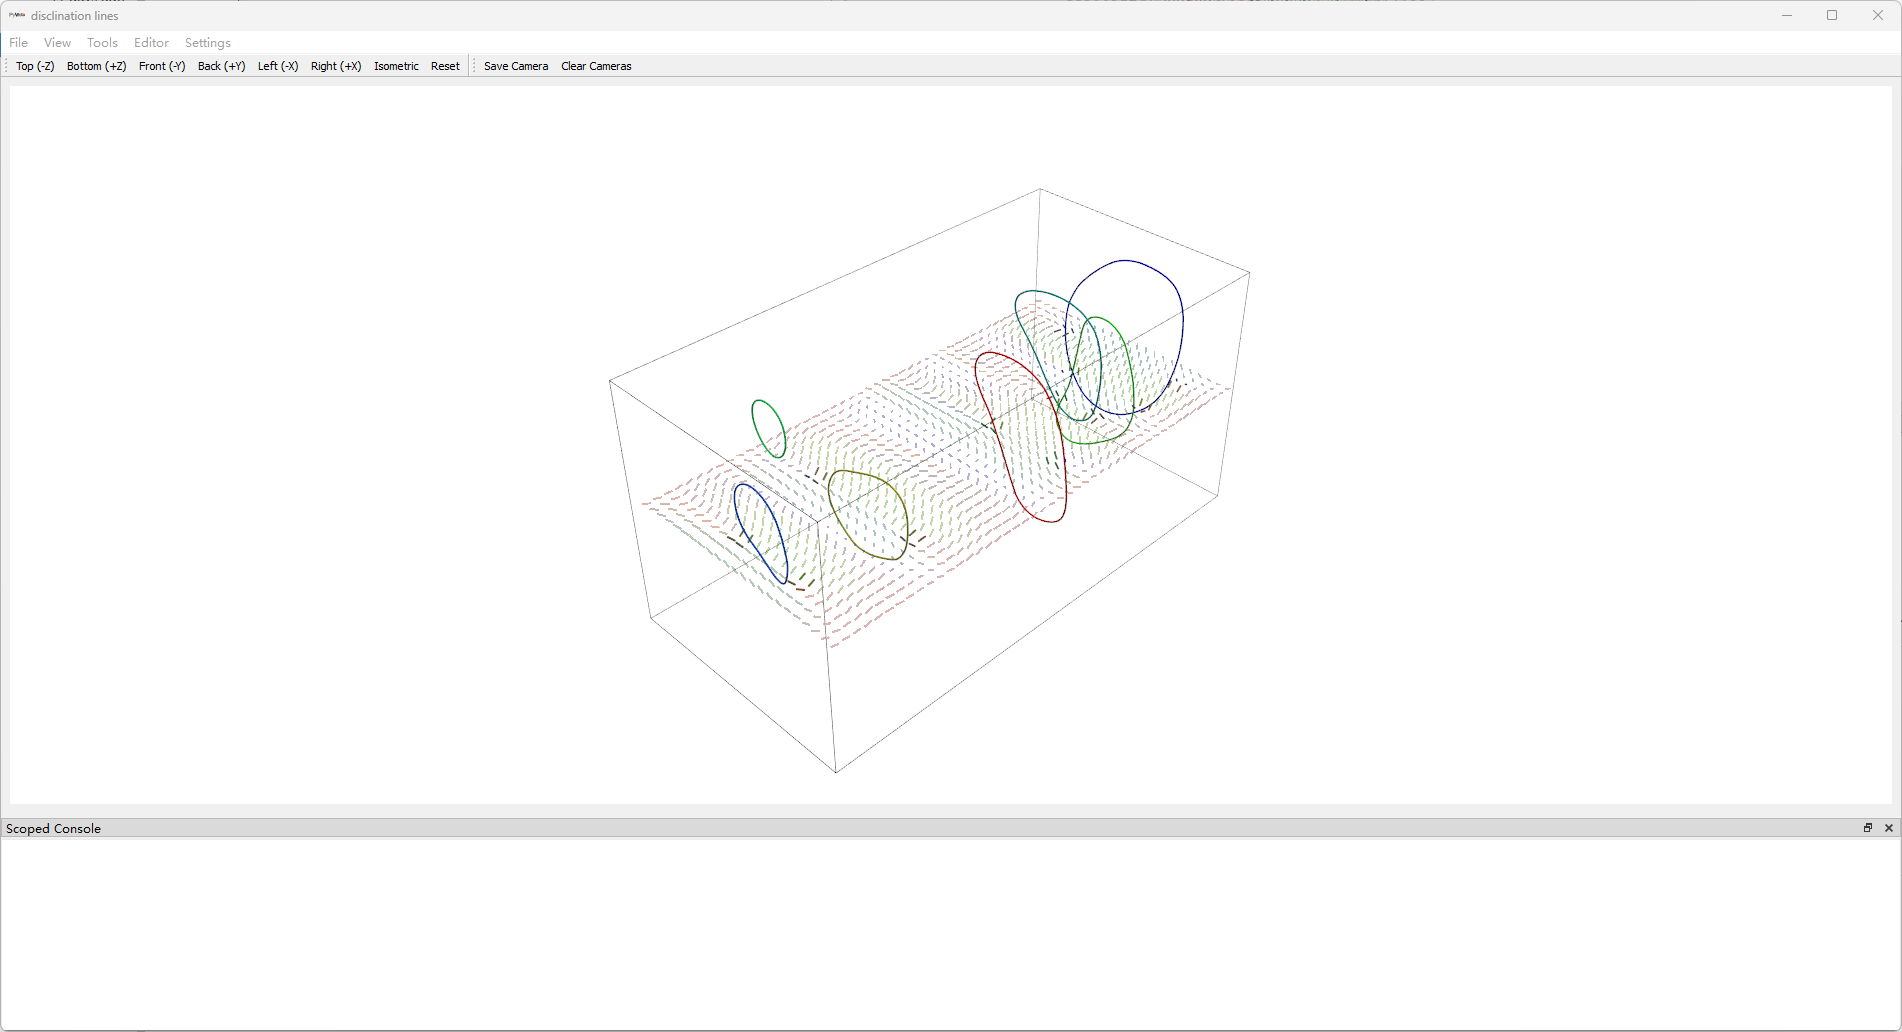

In [4]:
display(
    Image(
        filename=str(
            REPO_ROOT / "tutorials" / "output" / "interact_with_figures" / "example.png"
        )
    )
)


## Built-in PyVista / VTK camera interactions

Before using the repository-specific interactions, it helps to get comfortable with the default camera controls. These are provided by PyVista or VTK itself.

<table style="font-size: 1.08em;">
  <thead>
    <tr>
      <th><strong>Mouse action</strong></th>
      <th><strong>Typical effect</strong></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><strong>Left-button drag</strong></td>
      <td>Rotate the camera around the scene</td>
    </tr>
    <tr>
      <td><strong>Mouse wheel scroll</strong></td>
      <td>Zoom in or out</td>
    </tr>
    <tr>
      <td><strong>Right-button drag</strong></td>
      <td>Zoom continuously by dragging</td>
    </tr>
    <tr>
      <td><strong>Middle-button drag</strong></td>
      <td>Translate or pan the camera</td>
    </tr>
  </tbody>
</table>

These controls are the fastest way to get a better global view before you start inspecting a specific object.

If you want to inspect the current figure-level options, open the figure window menu bar, go to `Settings`, and choose `Show Figure Options`. In the current implementation, this opens a dialog that shows the `PlotFigure` option snapshot captured when the dialog was opened.

The screenshot below is one example. It shows the figure options of the unmodified figure produced earlier by `quick_visualize_Q()`. #!!! 在后面加上内容，具体PlotFigure的相关属性的定义与控制台行为请参考PlotFigure的说明文档。此外，



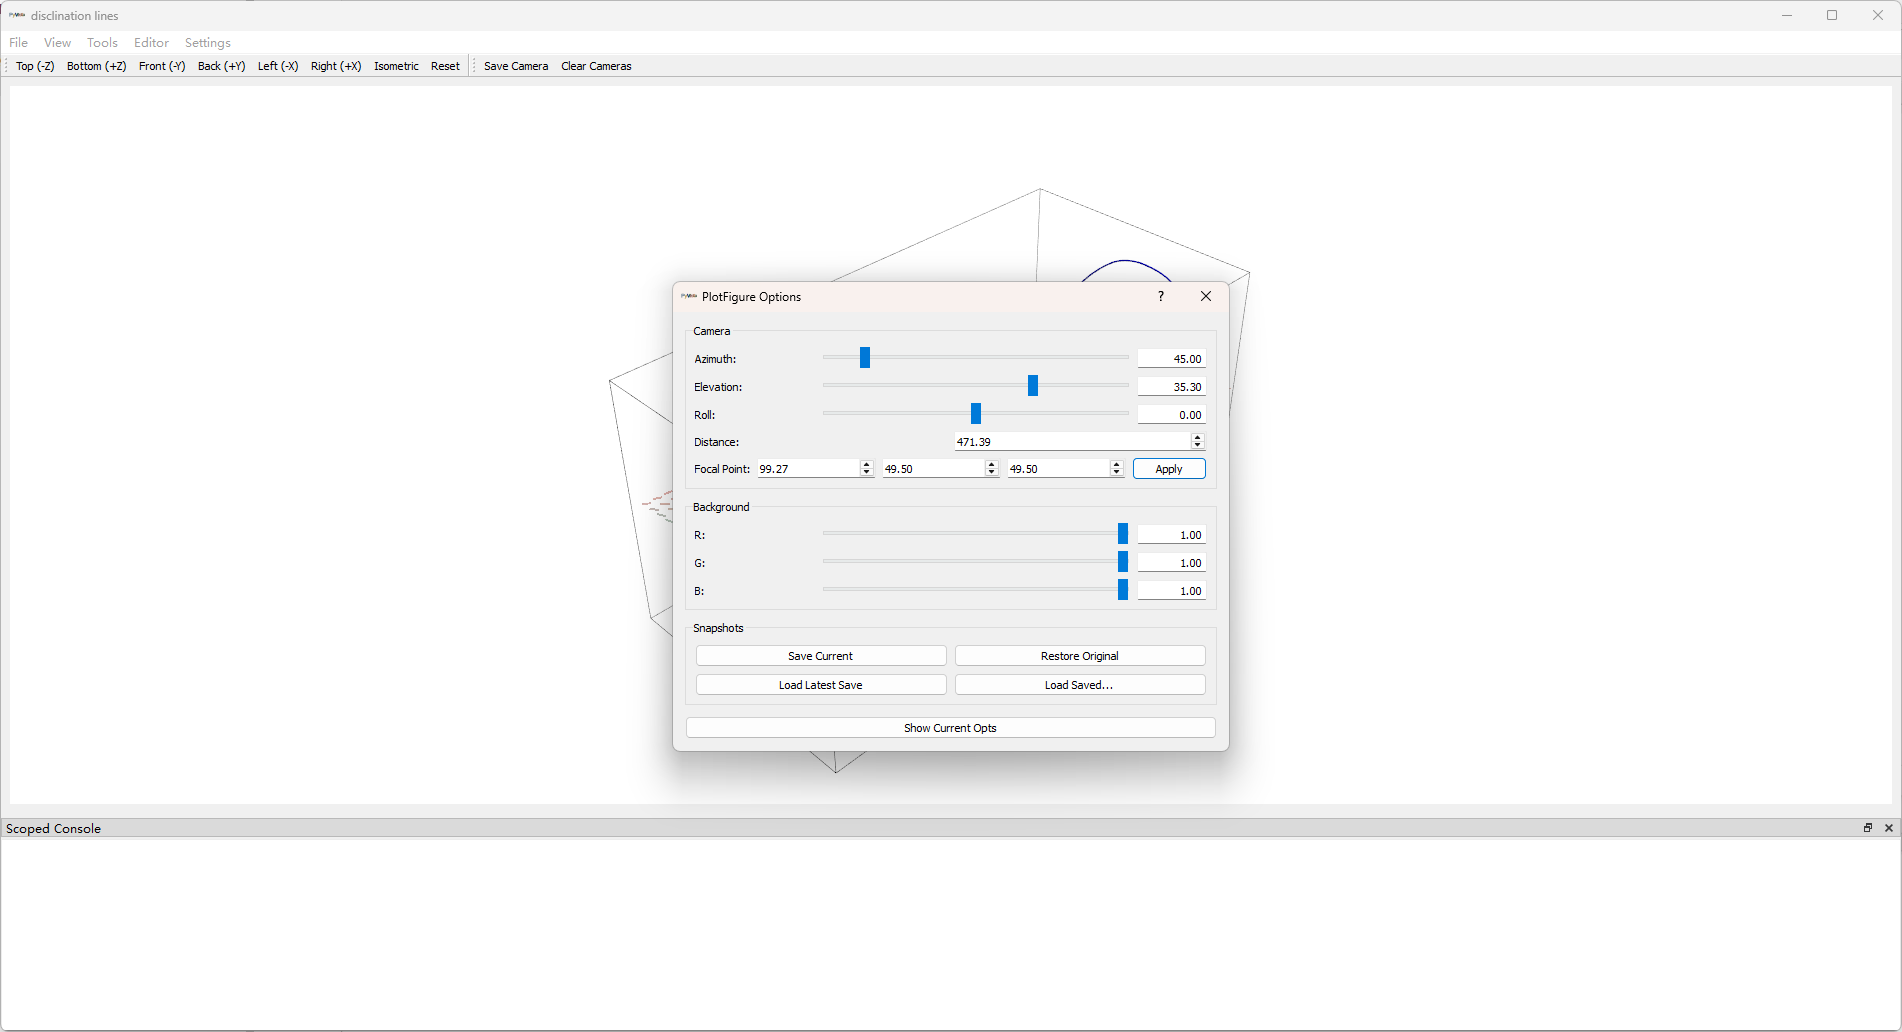

In [10]:
display(
    Image(
        filename=str(
            REPO_ROOT
            / "tutorials"
            / "output"
            / "interact_with_figures"
            / "figure_opts.png"
        )
    )
)


## Repository-specific glyph interactions

On top of the camera controls, this repository adds object-level interactions for plotted glyphs.

In the current implementation, the three most important ones are:

<div style="font-size: 1.08em; border: 2px solid #9aa7b1; border-radius: 8px; padding: 0.8em 1em; background-color: #f7f9fb;">
  <ul>
    <li><strong>left double-click on a glyph</strong></li>
    <li><strong>right click on a glyph</strong></li>
    <li><strong>right double-click on a glyph</strong></li>
  </ul>
</div>

These interactions work on plotted objects such as disclination-line tubes and director rods. They do not do anything useful if you click on empty background.

In the next three sections, we introduce these interactions one by one.

## Left double-click on a glyph

A left double-click is used for point-level inspection.

<div style="font-size: 1.08em; border: 2px solid #9aa7b1; border-radius: 8px; padding: 0.8em 1em; background-color: #f7f9fb;">
<strong>Highlight the clicked point:</strong> 
<ul>
  <li>it adds a numbered marker at the picked position</li>
  <li>if you double-click near an existing marker, it removes the nearest marker instead of adding a new one</li>
  <li>it reports information about the picked location in the console</li>
</ul>
</div>

The marker is drawn on a separate overlay layer rather than becoming part of the glyph geometry itself. That makes it easier to keep the picked point readable while you continue rotating, zooming, or adjusting the object visually, because the marker is meant to stay a lightweight inspection aid instead of changing the plotted data object.

In general, the reported output includes the name of the glyph you double-clicked, geometry and plotting information associated with the marker position, and some glyph-specific values when that object type exposes them.

The exact reported information depends on the glyph type. Take line-like glyphs for example, one useful quantity is often the normalized position along the line, usually written as `u_percent`. That gives you a simple one-dimensional label for where you clicked along the line.

After changing camera parameters or some other display settings, you may occasionally need to left click once on the empty background to force the marker layer to refresh together with the rest of the scene.

The figure below shows one example: a left double-click on the green disclination ring creates marker `#1` at the picked position.



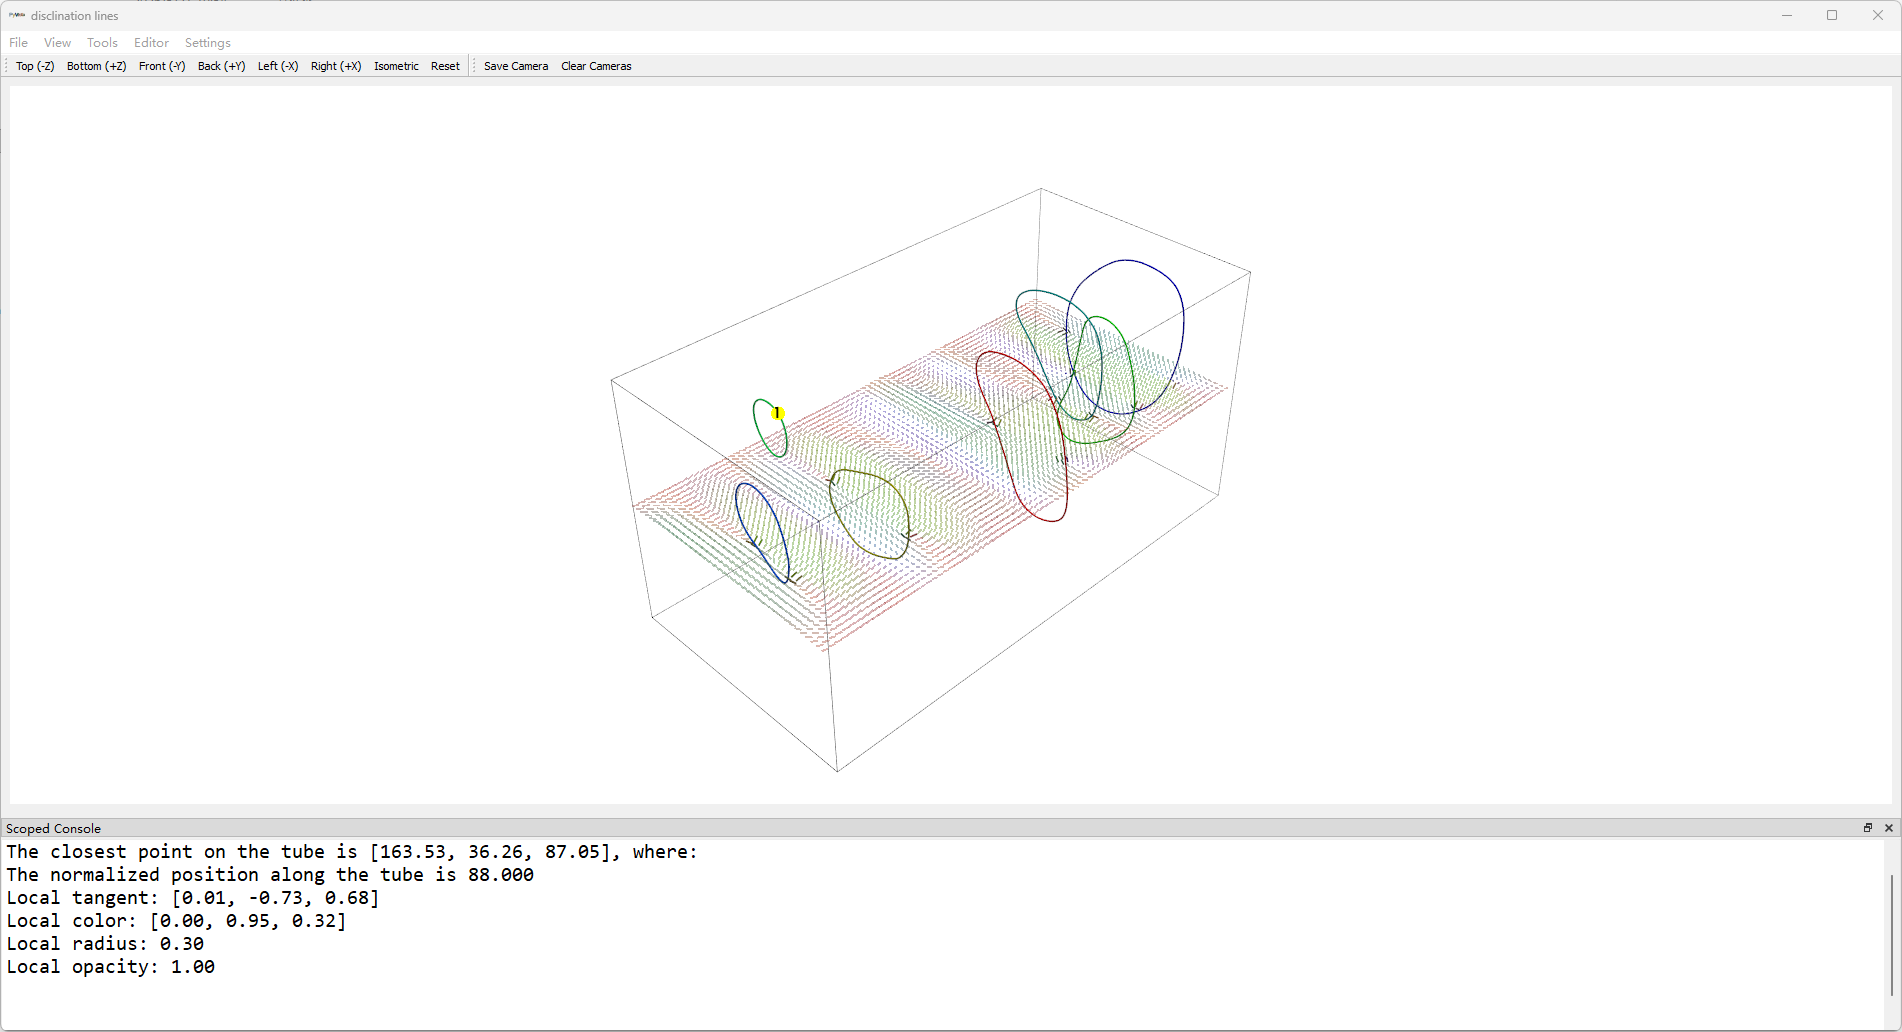

In [6]:
display(
    Image(
        filename=str(
            REPO_ROOT
            / "tutorials"
            / "output"
            / "interact_with_figures"
            / "left_double.png"
        )
    )
)


## Right click on a glyph

A right click is used for object-level identification.

<div style="font-size: 1.08em; border: 2px solid #9aa7b1; border-radius: 8px; padding: 0.8em 1em; background-color: #f7f9fb;">
<strong>Highlight the clicked glyph:</strong> 
<ul>
  <li>it toggles a silhouette highlight around the picked glyph</li>
  <li>it prints an object summary in the figure console</li>
  <li>the silhouette would disappear if it is right clicked again</li>
</ul>
</div>

This is especially useful when several plotted objects overlap visually and you want to confirm exactly which one you are looking at. It is also a simple way to show someone else which plotted object you are currently talking about before you continue discussing or adjusting it.

The figure below shows one example: a right click on the green disclination ring turns on its silhouette highlight so the selected object is easy to recognize.



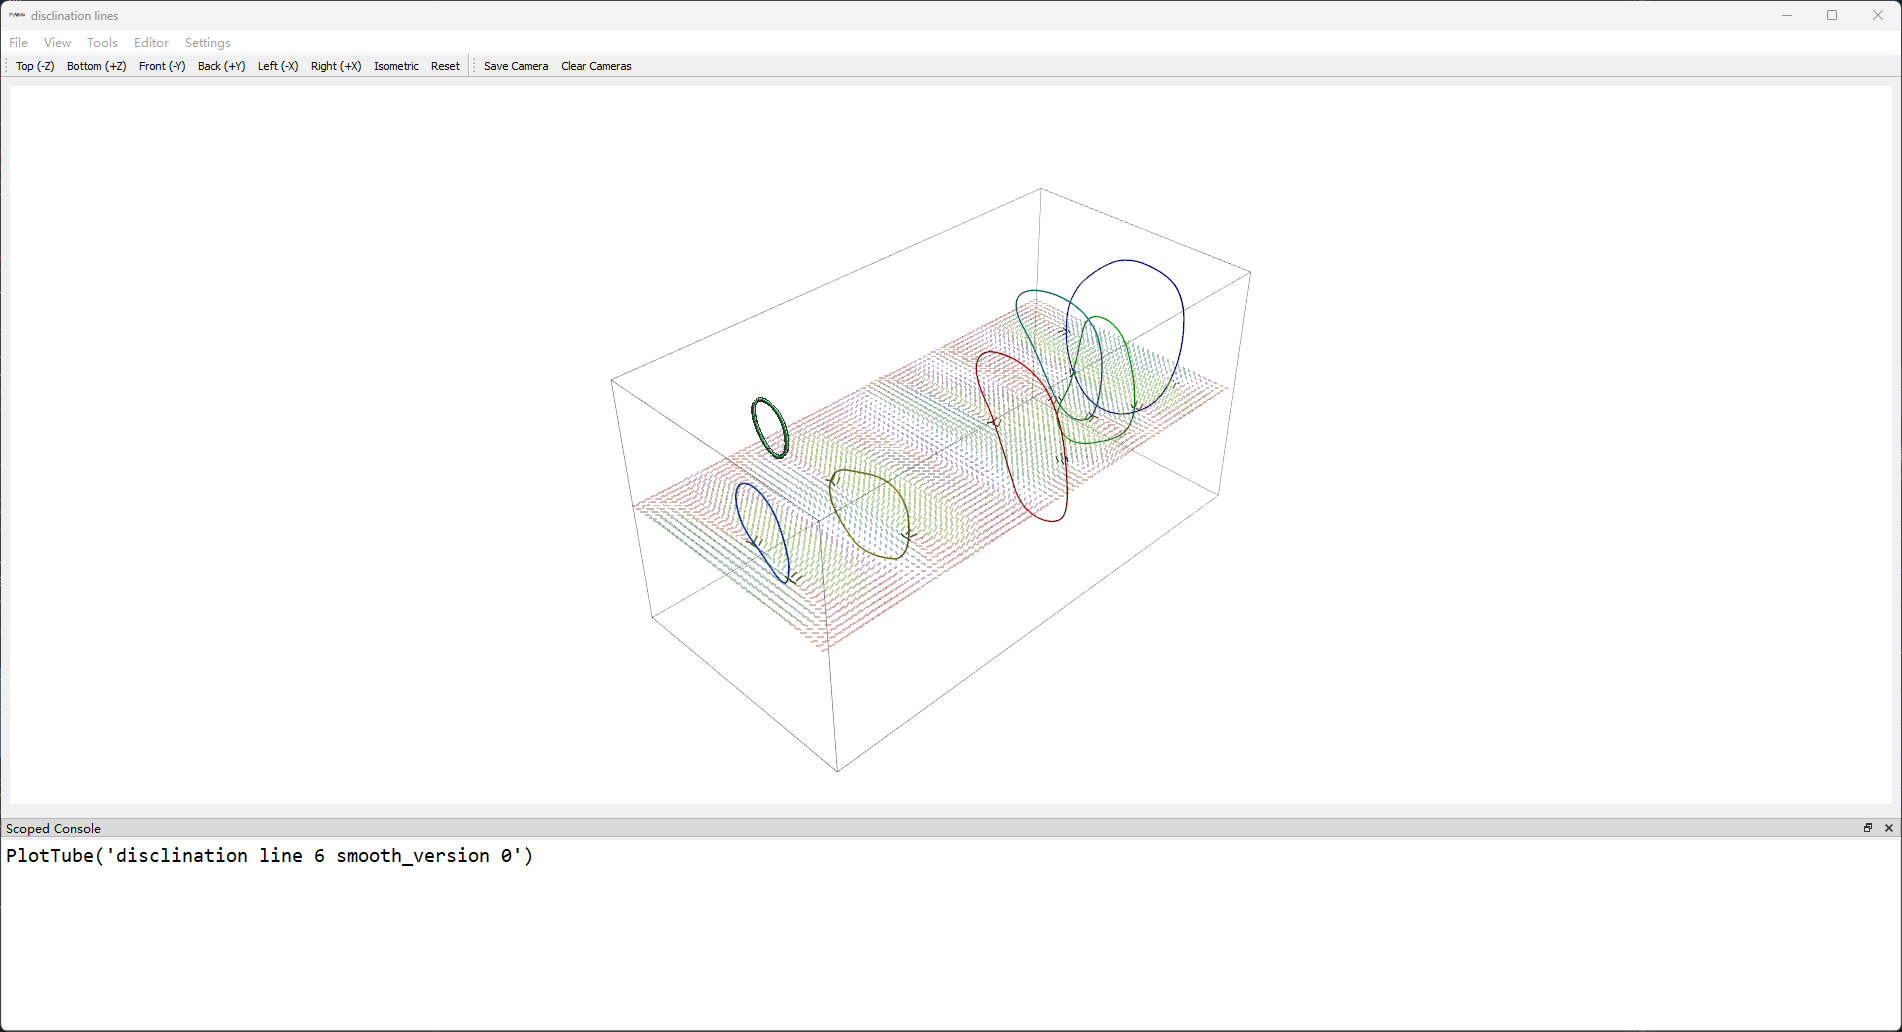

In [7]:
display(
    Image(
        filename=str(
            REPO_ROOT
            / "tutorials"
            / "output"
            / "interact_with_figures"
            / "right_single.png"
        )
    )
)


## Right double-click on a glyph

A right double-click opens a live interaction panel for the picked glyph.

<div style="font-size: 1.08em; border: 2px solid #9aa7b1; border-radius: 8px; padding: 0.8em 1em; background-color: #f7f9fb;">
<strong>Control the picked glyph interactively with a panel:</strong> 
<ul>
  <li>it opens the glyph-specific control panel(s)</li>
  <li>the available controls depend on the picked object type</li>
  <li>changes made in the panel are meant for live visual adjustment</li>
</ul>
</div>


This is the fastest way to explore visual settings without rewriting the plotting code immediately.

Also note that some glyphs may open more than one control panel at the same time. In the current example, if you right double-click a director, the interaction will open both the director's own panel and the panel for the supporting grid that the director is drawn on (see figure below). That makes it possible to adjust not only the director display itself, but also grid-related settings such as the grid normal direction and the grid density.

The figure below shows one example of this multi-panel behavior, where the directors in the example above is double right clicked. The exact control layout, widget styling, spacing, and other UI details may vary across different local machines and display configurations.



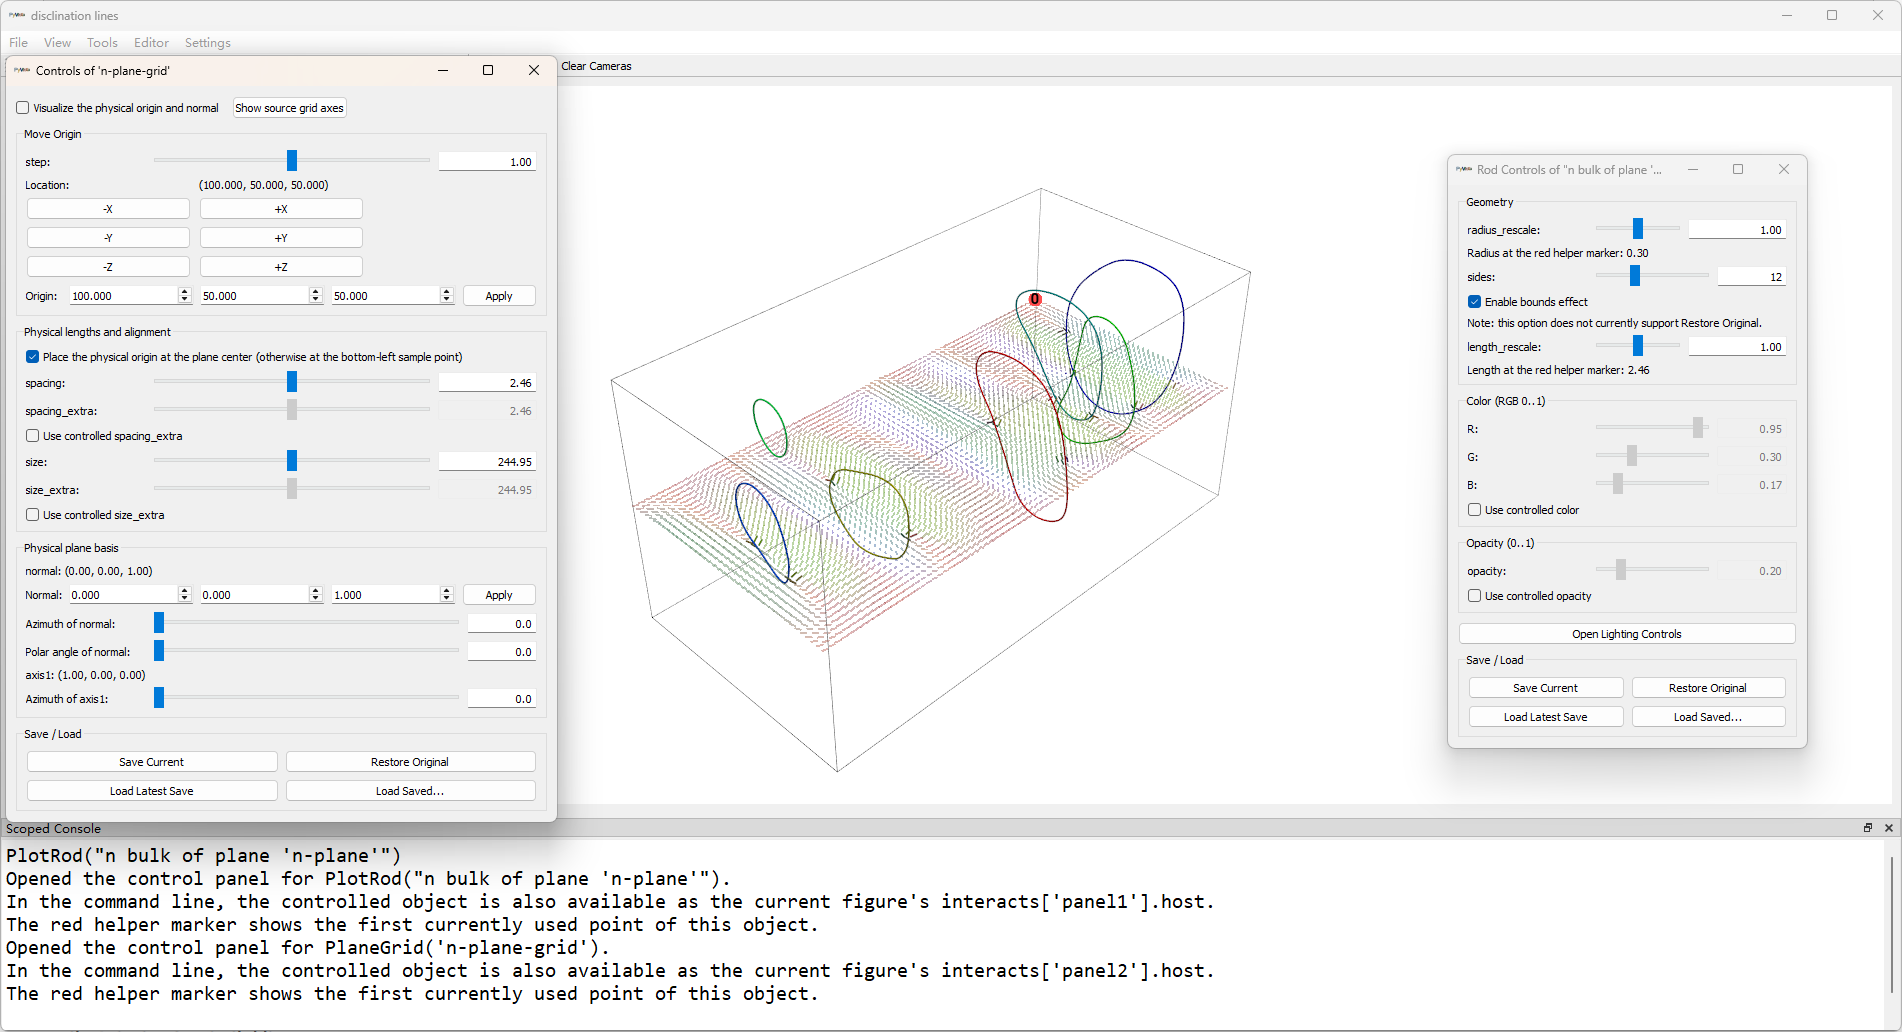

In [8]:
display(
    Image(
        filename=str(
            REPO_ROOT
            / "tutorials"
            / "output"
            / "interact_with_figures"
            / "right_double.png"
        )
    )
)



Notice that a red-background marker labeled 0 appears here (in the upper-right corner of the director plane). This is an additional feature generated when the console is opened for the director plane in the current example, and it may not exist in every console implementation. The red background and the 0 label are intentionally used to distinguish it from the marker created by double-clicking with the left mouse button, which is used to emphasize the clicked position as introduced in the previous section.

The functions in the control panel vary significantly in different glyphs. However, the most common functions are the `Save / Load` actions at the bottom. These buttons are useful when you want to explore several visual settings without losing a configuration that already looks good:

- `Save Current` stores the current parameter state using an automatically generated timestamped name.
- `Restore Original` returns to the state captured when this control panel was first opened.
- `Load Latest Save` restores the most recent snapshot created from this panel.
- `Load Saved...` lets you choose one available saved snapshot and restore it.

In practice, a convenient workflow is to first save one baseline state, then try a few aggressive adjustments, and finally load either the original state or one of your saved snapshots if the new result is not what you want.

<div style="font-size: 1.08em; border: 2px solid #9aa7b1; border-radius: 8px; padding: 0.8em 1em; background-color: #f7f9fb;">
    <strong>Control the picked glyph interactively from the command line:</strong>
</div>

Besides modifying an object through the live control panel, you can also edit it directly from the command line. This approach is often more convenient when you need to make precise adjustments, apply the same change programmatically, or inspect multiple attributes in sequence. In addition, some attributes are not exposed in the control panel and can only be modified from the command line.

Of course, command-line modification requires you to know how to access the corresponding object, and that object is not always easy to locate from its original variable name. To make this easier, opening a control panel automatically prints a convenient access path in the console. In the common case, the controlled object is available as the current figure's `interacts['panelN'].host`, where `panelN` is the panel name assigned when that panel is opened.

So a practical workflow is:

1. Right double-click the target glyph to open its control panel.
2. Look at the console message that reports the command-line access path.
3. Use that object in the command line for direct inspection or modification.

In this notebook, `figure_example` is the interactive scene object returned earlier when we opened the visualization:

```python
Q_obj, figure_example = nematics3d.quick_visualize_Q(
    Q=Q_data,
)
```

In the right-double-click example image shown above, if you right double-click one of the translucent directors in the plane, the current implementation opens the director-related control panels and prints the corresponding command-line access path in the console. Let's look at the path `interacts['panel2'].host`, which refers to the supporting `PlaneGrid` object as the lattice grid for the directors sampling. The code cell below demonstrates an example to modify the object from the command line. First, it prints `repr(figure_example.interacts['panel2'].host.opts)` so you can inspect the current `PlaneGrid` options directly from the command line. Then it modifies `figure_example.interacts['panel2'].host.opts.normal = (1, 1, 0)` to change the grid normal direction programmatically. 


In [9]:
# The code below can only be run after you actually double-click a director in the displayed figure and open its console panel. 
# If this is not the first time that console has been opened for the current figure, the panel number shown in the console may be different. 
# Please follow the console message shown after you double-click the director.

print(repr(figure_example.interacts['panel2'].host.opts))
figure_example.interacts['panel2'].host.opts.normal = (1,1,0)

KeyError: "No object with name 'panel2' found in Registry 'interact panel manager'."

## Summary

In this notebook, we used `quick_visualize_Q()` to open one interactive figure and then focused on how to use it.

The next natural extension is to show how these interactions connect to more detailed follow-up analysis after you have identified an interesting defect line or region.